### Graph의 실행 흐름 중간에 사용자가 직접 개입하는 방법

> **⚠️ 인터럽트(Interrupt) 핵심 원칙**
> 1. **노드 재실행 주의**: `interrupt()`로 일시 정지된 노드가 사용자 응답을 받아 재개(resume)될 때, 멈춘 곳이 아닌 **노드의 처음부터 다시 실행**됩니다. 부수 효과(Side effect)가 있는 코드는 중복 실행될 수 있으므로 주의해야 합니다.
> 2. **Checkpointer 필수**: 그래프 상태를 저장하고 복구하려면 Checkpointer가 반드시 필요합니다. 실무에서는 `SqliteSaver`와 같은 영구 저장소를 사용하는 것이 안전합니다.
> 3. **API 권장사항**: 본 예제는 학습의 직관성을 위해 `invoke()`를 사용하지만, 프로덕션 환경에서는 이벤트 스트리밍 방식인 `stream_events(version='v3')` 사용이 공식적으로 권장됩니다.

In [1]:
from typing_extensions import TypedDict
from typing import Annotated
import operator

import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

class State(TypedDict):
    messages: Annotated[list[str], operator.add]


In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt

def process_task(state: State):
    print("\n=== process_task node 시작 ===")
    print(f"현재 messages: {state['messages']}")

    approval = interrupt("계속 진행할까요? (True/False)")
    print("interrupt 발생! (사용자 승인 대기)")

    print(f"\n사용자가 응답했습니다: {approval}")

    if approval:
        print("승인되었습니다! 작업을 진행합니다.")
        return {"messages": ["작업이 성공적으로 완료되었습니다!"]}
    else:
        print("거부되었습니다. 작업을 취소합니다.")
        return {"messages": ["작업이 취소되었습니다."]}

graph_builder = StateGraph(State)

graph_builder.add_node("process_task", process_task)

graph_builder.add_edge(START, "process_task")
graph_builder.add_edge("process_task", END)

checkpointer = SqliteSaver(sqlite3.connect("./db/checkpoints.db", check_same_thread=False))

# HITL이 가능하려면 반드시 Checkpointer(상태 저장소)가 필요
graph = graph_builder.compile(checkpointer=checkpointer)

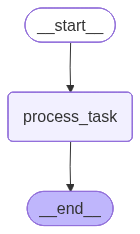

In [3]:
graph

In [4]:
config = {"configurable": {"thread_id": "thread_02"}}
result = graph.invoke({"messages": ["시작"]}, config)


=== process_task node 시작 ===
현재 messages: ['시작']


In [5]:
result.get("messages")

['시작']

In [6]:
result.get("__interrupt__")

[Interrupt(value='계속 진행할까요? (True/False)', id='3cbcc2288f4bf58fa99a7537d091fd0a')]

In [7]:
state = graph.get_state(config)

In [9]:
state

StateSnapshot(values={'messages': ['시작']}, next=('process_task',), config={'configurable': {'thread_id': 'thread_02', 'checkpoint_ns': '', 'checkpoint_id': '1f1662a5-d47f-6f83-8000-b664d4edf87d'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-12T06:45:56.485517+00:00', parent_config={'configurable': {'thread_id': 'thread_02', 'checkpoint_ns': '', 'checkpoint_id': '1f1662a5-d47c-614c-bfff-bb95f6ca3d81'}}, tasks=(PregelTask(id='f319d3e6-6486-a588-8143-7168d3563c69', name='process_task', path=('__pregel_pull', 'process_task'), error=None, interrupts=(Interrupt(value='계속 진행할까요? (True/False)', id='3cbcc2288f4bf58fa99a7537d091fd0a'),), state=None, result=None),), interrupts=(Interrupt(value='계속 진행할까요? (True/False)', id='3cbcc2288f4bf58fa99a7537d091fd0a'),))

In [10]:
state.next

('process_task',)

In [11]:
state.values.get('messages', [])

['시작']

---

#### 실행 재개

사용자 "승인"하기

In [12]:
state.next

('process_task',)

In [13]:
state.interrupts

(Interrupt(value='계속 진행할까요? (True/False)', id='3cbcc2288f4bf58fa99a7537d091fd0a'),)

In [14]:
prompt = state.interrupts[0].value
user_input = input(prompt + " > ") # 재개(resume)를 위해 사용자 입력 받기


In [15]:
from langgraph.types import interrupt, Command

user_bool = user_input.lower() == "true"
result = graph.invoke(Command(resume=user_bool), config)


=== process_task node 시작 ===
현재 messages: ['시작']
interrupt 발생! (사용자 승인 대기)

사용자가 응답했습니다: True
승인되었습니다! 작업을 진행합니다.


In [16]:
result['messages']

['시작', '작업이 성공적으로 완료되었습니다!']

---

In [17]:
config = {"configurable": {"thread_id": "thread_03"}}
result = graph.invoke({"messages": ["시작"]}, config)


=== process_task node 시작 ===
현재 messages: ['시작']


In [18]:
result.get("messages")

['시작']

In [20]:
result.get("__interrupt__")

[Interrupt(value='계속 진행할까요? (True/False)', id='1669bd75af852bbf1922578a1dea6c92')]

In [21]:
prompt = state.interrupts[0].value
user_input = input(prompt + " > ") # 재개(resume)를 위해 사용자 입력 받기

In [22]:
from langgraph.types import interrupt, Command

user_bool = user_input.lower() == "true"
result = graph.invoke(Command(resume=user_bool), config)


=== process_task node 시작 ===
현재 messages: ['시작']
interrupt 발생! (사용자 승인 대기)

사용자가 응답했습니다: False
거부되었습니다. 작업을 취소합니다.
